### Setup ###

In [6]:
import os
import ssl
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Mac-specific fixes
ssl._create_default_https_context = ssl._create_unverified_context
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

### Data Loading

In [7]:
# Load MNIST
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape and Normalize
x_train = x_train.reshape(x_train.shape[0], 784).astype('float32') / 255
x_test = x_test.reshape(x_test.shape[0], 784).astype('float32') / 255

# One-hot encoding
y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(f"Data ready. Training shape: {x_train.shape}")

Data ready. Training shape: (60000, 784)


### Architecture

In [8]:
model = keras.Sequential([
    layers.Dense(256, activation="relu", input_shape=(784,)),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

# Use legacy optimizer for Apple Silicon speed
optimizer = tf.keras.optimizers.legacy.RMSprop()

model.compile(
    loss="categorical_crossentropy",
    optimizer=optimizer,
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 256)               200960    
                                                                 
 dropout_2 (Dropout)         (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 dropout_3 (Dropout)         (None, 128)               0         
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 235146 (918.54 KB)
Trainable params: 235146 (918.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Training

In [9]:
# This is the step that actually learns
history = model.fit(
    x_train, y_train,
    epochs=10, # Start with 10 epochs to see if it works
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 [==============================] - 1s 2ms/step - loss: 0.4318 - accuracy: 0.8697 - val_loss: 0.1638 - val_accuracy: 0.9513
Epoch 2/10
375/375 [==============================] - 1s 2ms/step - loss: 0.2045 - accuracy: 0.9385 - val_loss: 0.1153 - val_accuracy: 0.9654
Epoch 3/10
375/375 [==============================] - 1s 2ms/step - loss: 0.1549 - accuracy: 0.9542 - val_loss: 0.1057 - val_accuracy: 0.9690
Epoch 4/10
375/375 [==============================] - 1s 2ms/step - loss: 0.1302 - accuracy: 0.9611 - val_loss: 0.0973 - val_accuracy: 0.9717
Epoch 5/10
375/375 [==============================] - 1s 2ms/step - loss: 0.1144 - accuracy: 0.9656 - val_loss: 0.0983 - val_accuracy: 0.9730
Epoch 6/10
375/375 [==============================] - 1s 2ms/step - loss: 0.1059 - accuracy: 0.9691 - val_loss: 0.0866 - val_accuracy: 0.9758
Epoch 7/10
375/375 [==============================] - 1s 2ms/step - loss: 0.0976 - accuracy: 0.9704 - val_loss: 0.0921 - val_accuracy: 0.9747
Epoch 

### Evaluation and Plotting

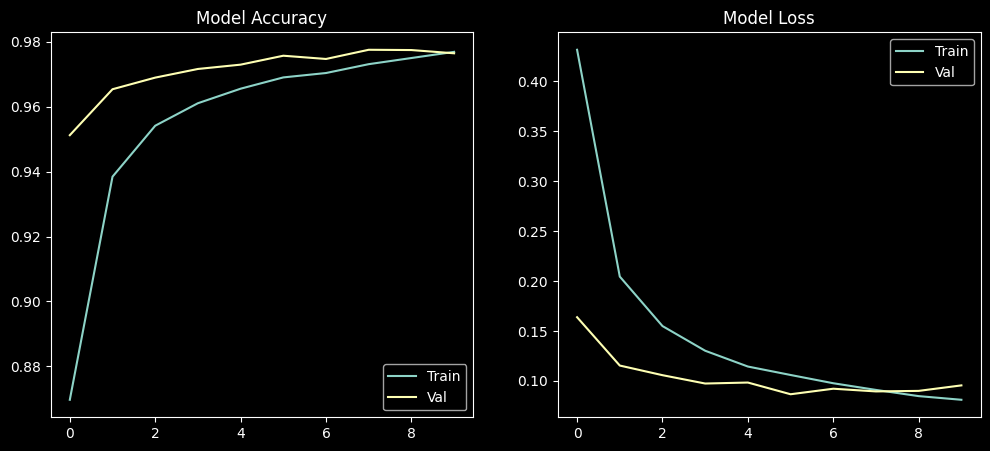

Test Accuracy: 0.9796


In [10]:
# 1. Plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Model Loss')
plt.legend()
plt.show()

# 2. Final Results
test_scores = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_scores[1]:.4f}")